# HW04: Problem 6: Feature Selection

## Description

In this problem we will work with the diabetes dataset from sklearn. This data set is for a regression problem where 10 features are used to predict the progression of diabetes. The dataset is described in more detail [here](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset). You task here is to use multiple techniques of feature selection to try to interpret the strength of the features in the dataset. You will need to use the following techniques:

- Pearson correlation coefficient using r_regression from sklearn (univariate feature selection)
- Mutual information using mutual_info_regression from sklearn (univariate feature selection)
- Random forest feature importance using RandomForestRegressor from sklearn (multivariate feature selection)
- Recursive feature elimination using sklearn.feature.selection.RFE with a Support Vector Regressor SVR (multivariate feature selection)

For each method you will need to plot the feature importance as a bar graph. The importance goes by different names in different algorithms. For example, in r_regression it is just the output (r value) and the mutual information in mutual_info_regression. In random variable it is called feature_importance_ and in RFE it is the ranking_. The bar graph will be sorted from most important features to least important features, with the y value being the importance of that feature, and the x value being the rank but labeled with the feature name.
You will also need to print out the top 5 features for each method. You will need to use the following code to load the data and split it into training and testing sets. You will need to use the training set for all of the feature selection methods.

* Are there 3 features that are selected in the top 5 by all 4 methods?
* If so, what are they?
* If not, what are the 3 features that are selected by the most methods?
* How would it be possible that univariate methods might select different features than multivariate methods?
* How does dependence between features affect the feature selection methods?

For good habits, make sure you split your code into training and testing. You may not even use the testing data but when you do any analysis such as feature selection, remember you must not use the testing data. You should also make sure you use the same random seed for all of your feature selection methods so that you can compare the results.

## Hints: In sorting features you use "arg" sort. This will return the indices of the sorted array. You can use these indices to sort the feature names.

This kind of code will be useful for plotting the bar graph:

```python
r_inds = np.argsort(np.abs(r_importance))[::-1]
fig, ax = plt.subplots()
rank = np.arange(len(data.feature_names))
ax.bar(rank, r_importance[r_inds])
ax.set_xticks(rank)
ax.set_xticklabels(np.array(data.feature_names)[r_inds])
```

In [1]:
# Some imports you will need
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from numpy import corrcoef
import seaborn as sns
from sklearn.feature_selection import r_regression
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## Loading and preparing the data

In [2]:
# Load the diabetes data set as X, y
X, y = load_diabetes(return_X_y=True)
# Load the diabetes data set as data to read the description
data = load_diabetes()

In [3]:
# Print out the DESCR attribute to inpect the variables
print(data.DESCR[:1200]) # preview the first section of the dataset description

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
# Print the array of feature names
print("Feature names:", data.feature_names)

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [5]:
# Split the Data into train/testing sets
# Feature selection must be performed using the training data only
# so that the test data remains completely unseen.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
# Check the shapes
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)


X_train: (353, 10) y_train: (353,)
X_test : (89, 10) y_test : (89,)


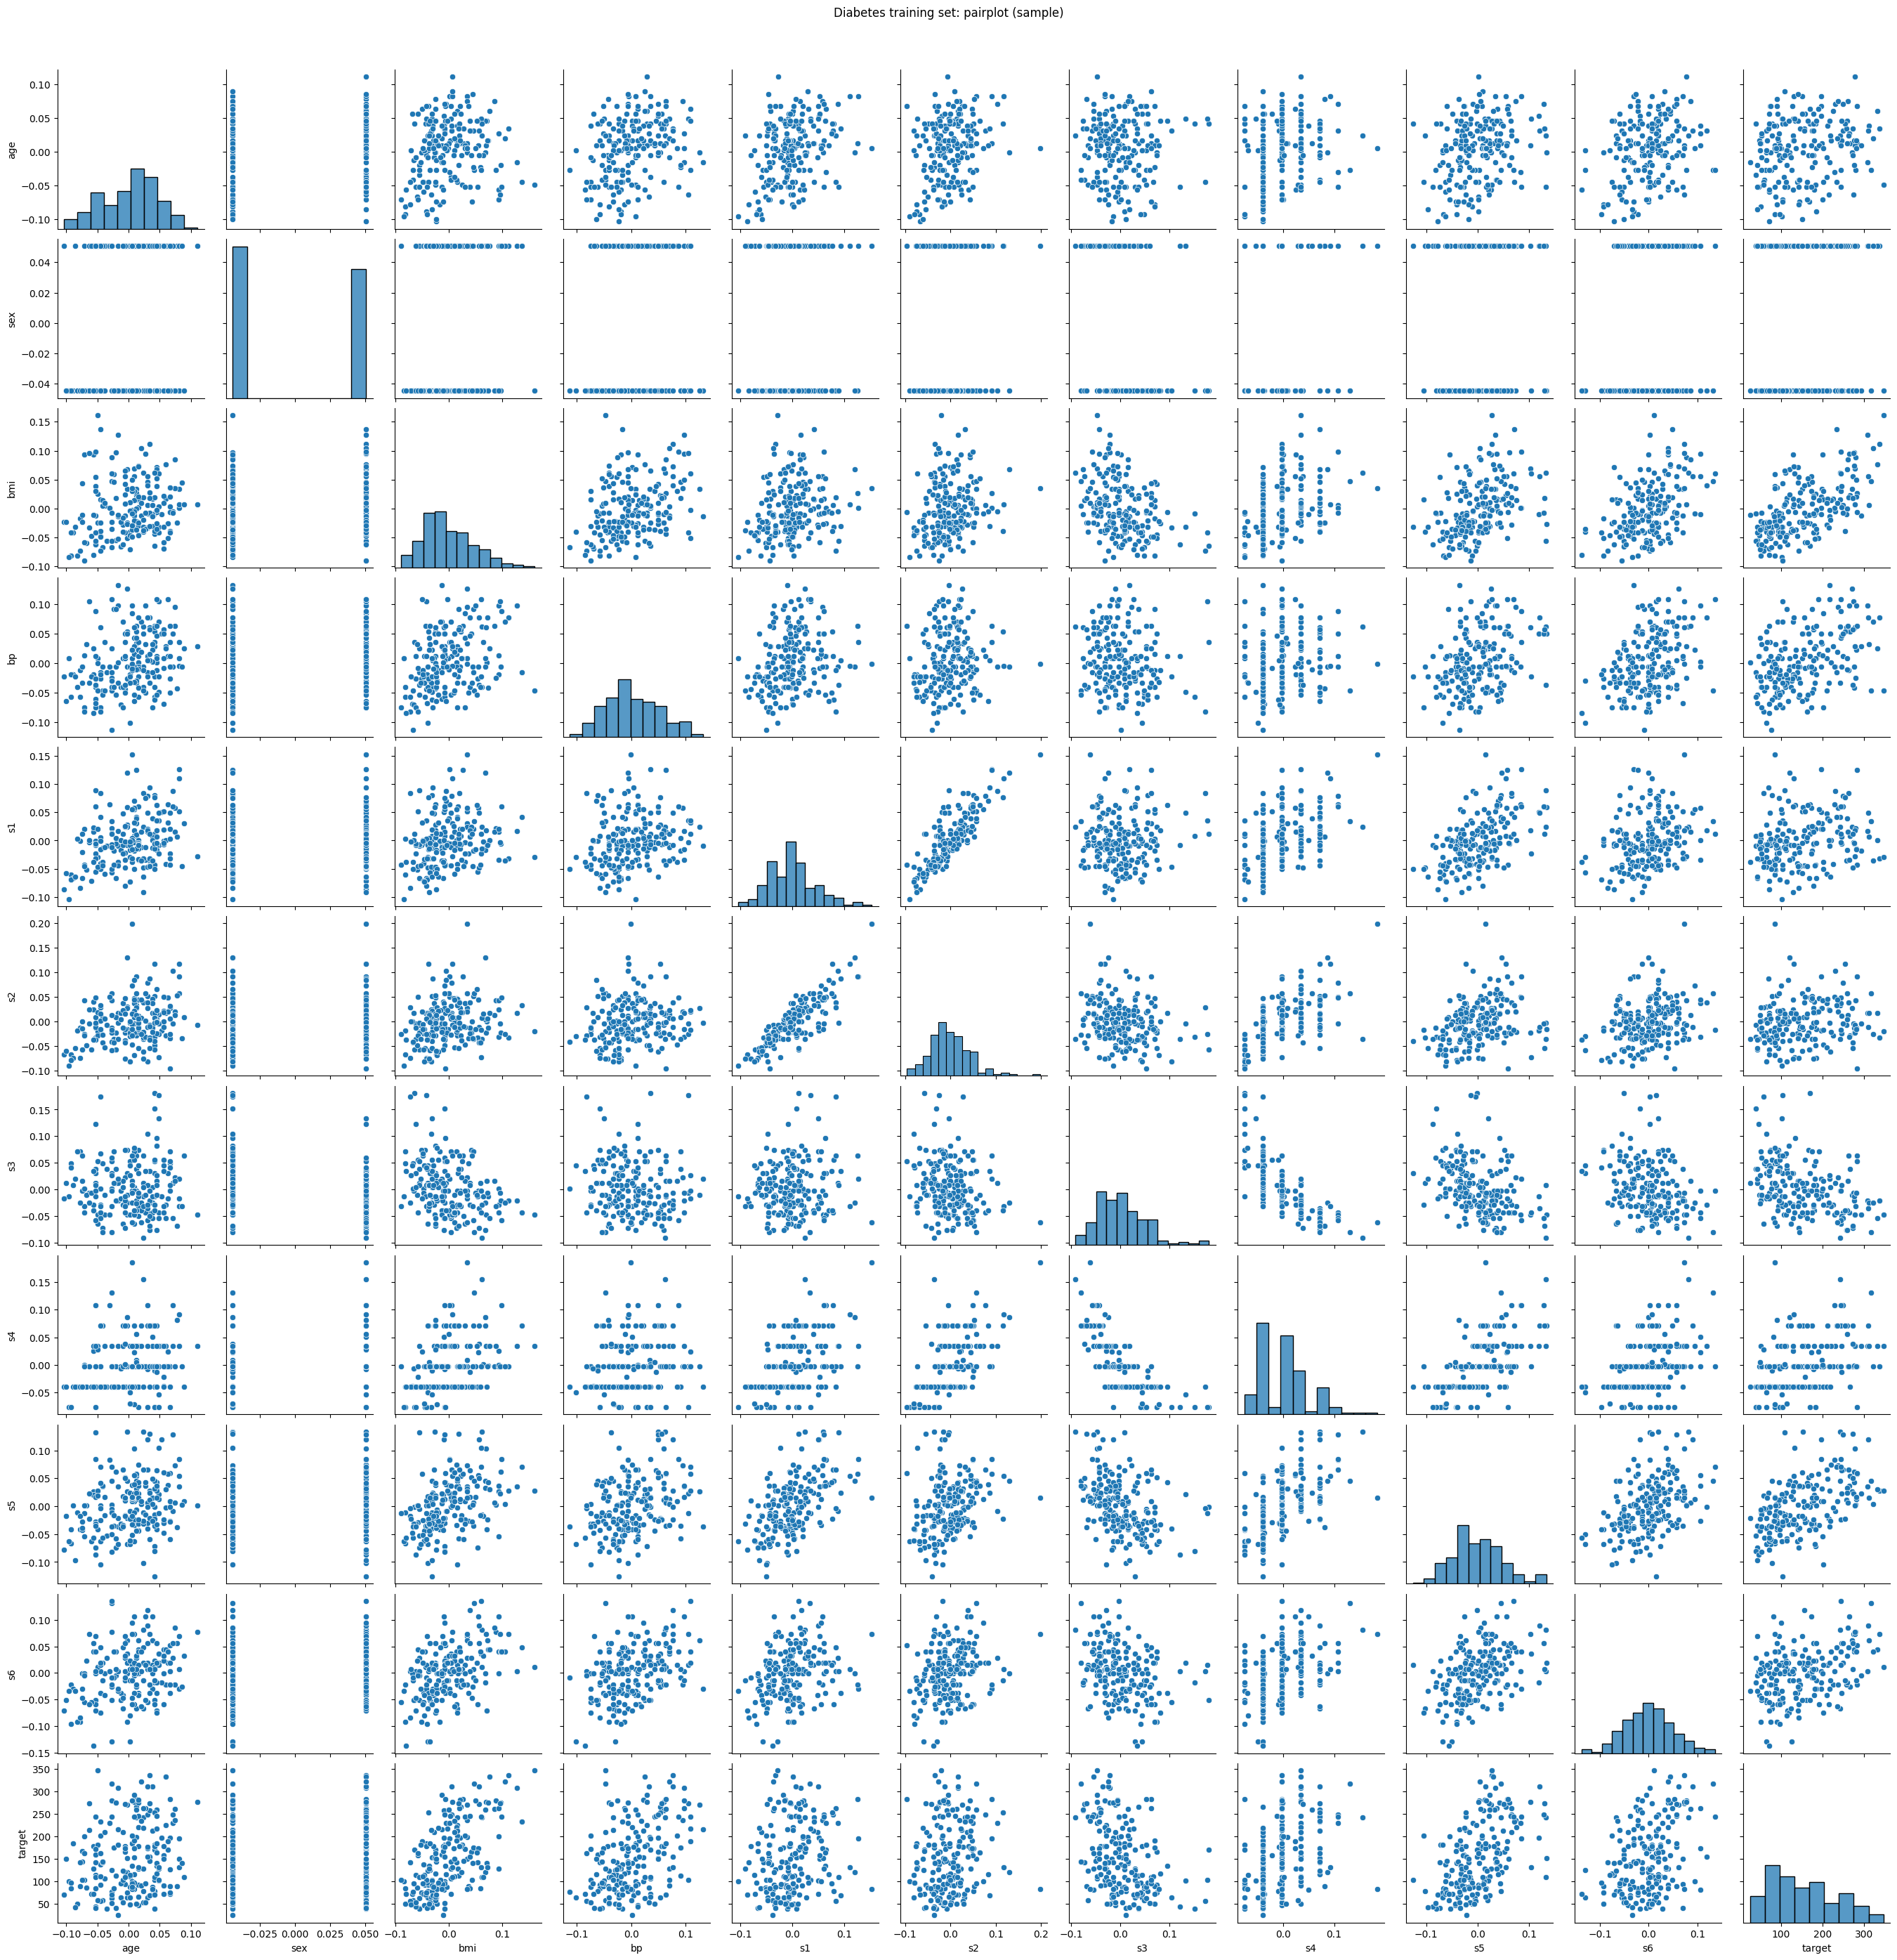

In [7]:
# Do a pair plot
# Since pair plot take time with the full dataset, I used a random subset to make it faster.

df_train = pd.DataFrame(X_train, columns=data.feature_names)
df_train["target"] = y_train

sample_df = df_train.sample(n=min(200, len(df_train)), random_state=42)

# Pairplot helps visually spot relationships and collinearity among variables.
sns.pairplot(sample_df, diag_kind="hist")
plt.suptitle("Diabetes training set: pairplot (sample)", y=1.02)
plt.show()

Q: What does the EDA tell you about the data?

Answer:

Looking at the pairplots and correlations, several patterns become clear: The outcome variable appears to increase most noticeably with bmi and s5, suggesting these two features have a strong positive connection with disease progression. Other variables such as bp, s4, and s6 also show positive trends, though not as strongly. In addition, some of the predictors are highly related to one another. In particular, several of the blood serum variables move together (for example, s1 and s2, as well as s3 and s4). This indicates multicollinearity, meaning some features contain overlapping information. Also,the relationships are not perfectly straight lines, and there are scattered points that suggest variability and possible outliers. Because of this, methods that only measure linear relationships might miss important patterns that nonlinear approaches could detect. Overall, these findings suggest it is reasonable to compare both simple (univariate) and more complex (multivariate) feature selection techniques.


## Univariate feature selection with r_regression

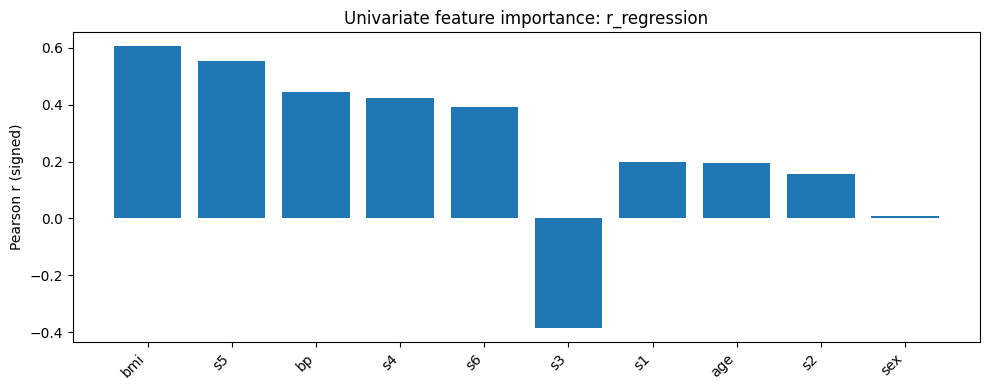

In [8]:
# Use r_regression to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph

# Compute Pearson correlation for each feature using the training data,
# rank features by the size of the correlation (absolute value),
# and display a bar chart showing both strength and direction of the relationship.
r_importance = r_regression(X_train, y_train)  # one r-value per feature
r_inds = np.argsort(np.abs(r_importance))[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
rank = np.arange(len(data.feature_names))
ax.bar(rank, r_importance[r_inds])
ax.set_xticks(rank)
ax.set_xticklabels(np.array(data.feature_names)[r_inds], rotation=45, ha="right")
ax.set_ylabel("Pearson r (signed)")
ax.set_title("Univariate feature importance: r_regression")
plt.tight_layout()
plt.show()



In [9]:
# print the top 5 features according to r_regression?
top5_r = np.array(data.feature_names)[r_inds[:5]]
top5_r_values = r_importance[r_inds[:5]]
print("Top 5 by |Pearson r|:")
for name, val in zip(top5_r, top5_r_values):
    print(f"  {name:>3s}: r = {val:+.4f}")



Top 5 by |Pearson r|:
  bmi: r = +0.6048
   s5: r = +0.5522
   bp: r = +0.4448
   s4: r = +0.4251
   s6: r = +0.3904


## Univariate feature selection with mutual information using mutual_info_regression

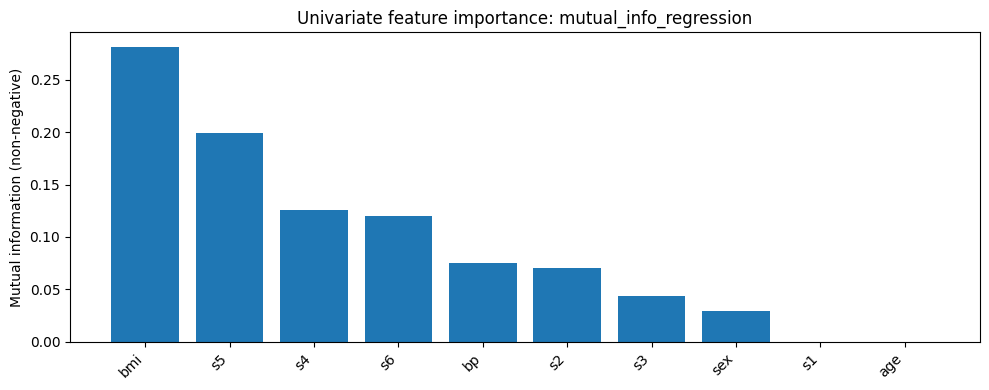

In [16]:
# Use mutual_info_regression to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph

mi_importance = mutual_info_regression(X_train, y_train, random_state=42)
mi_inds = np.argsort(mi_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
rank = np.arange(len(data.feature_names))
ax.bar(rank, mi_importance[mi_inds])
ax.set_xticks(rank)
ax.set_xticklabels(np.array(data.feature_names)[mi_inds], rotation=45, ha="right")
ax.set_ylabel("Mutual information (non-negative)")
ax.set_title("Univariate feature importance: mutual_info_regression")
plt.tight_layout()
plt.show()


In [17]:
# What are the top 5 features according to mutual_info_regression?
top5_mi = np.array(data.feature_names)[mi_inds[:5]]
top5_mi_values = mi_importance[mi_inds[:5]]
print("Top 5 by mutual information:")
for name, val in zip(top5_mi, top5_mi_values):
    print(f"  {name:>3s}: MI = {val:.4f}")

Top 5 by mutual information:
  bmi: MI = 0.2811
   s5: MI = 0.1990
   s4: MI = 0.1262
   s6: MI = 0.1204
   bp: MI = 0.0756


## Multivariate feature selection with Random Forest feature_importance_

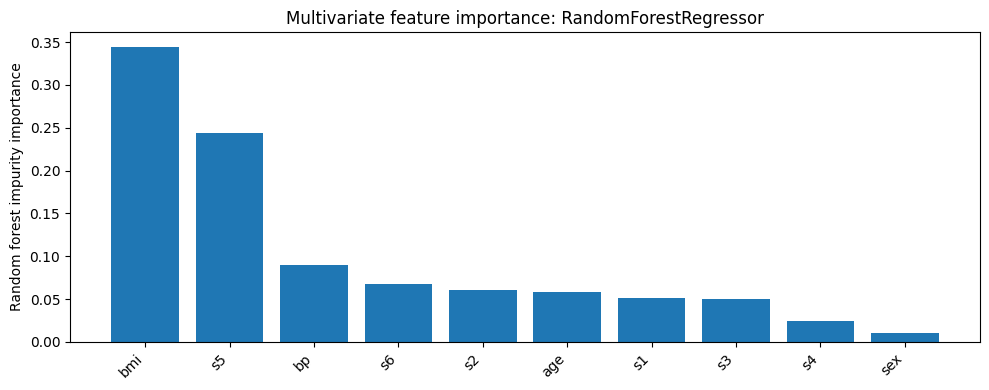

In [18]:
# Use random forest feature_importance_ to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
rf.fit(X_train, y_train)
rf_importance = rf.feature_importances_
rf_inds = np.argsort(rf_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
rank = np.arange(len(data.feature_names))
ax.bar(rank, rf_importance[rf_inds])
ax.set_xticks(rank)
ax.set_xticklabels(np.array(data.feature_names)[rf_inds], rotation=45, ha="right")
ax.set_ylabel("Random forest impurity importance")
ax.set_title("Multivariate feature importance: RandomForestRegressor")
plt.tight_layout()
plt.show()


In [19]:
# What are the top 5 features according to random forest feature_importance_?
top5_rf = np.array(data.feature_names)[rf_inds[:5]]
top5_rf_values = rf_importance[rf_inds[:5]]
print("Top 5 by Random Forest importance:")
for name, val in zip(top5_rf, top5_rf_values):
    print(f"  {name:>3s}: importance = {val:.4f}")


Top 5 by Random Forest importance:
  bmi: importance = 0.3442
   s5: importance = 0.2443
   bp: importance = 0.0895
   s6: importance = 0.0678
   s2: importance = 0.0602


## Multivariate feature selection with recursive feature elimination (RFE) using a support vector regressor

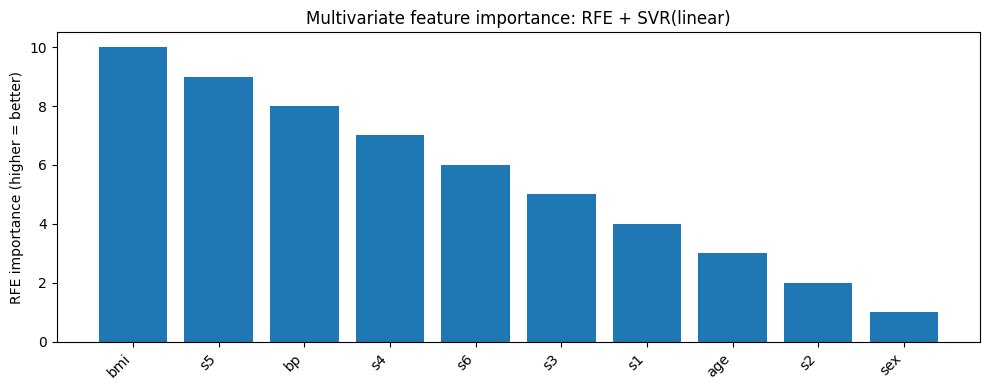

In [20]:
# Use recursive feature elimination (RFE) with a support vector regressor
# to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph

svr = SVR(kernel="linear")
rfe = RFE(estimator=svr, n_features_to_select=1, step=1)
rfe.fit(X_train, y_train)

# In RFE, smaller ranking means more important (1 = best).
# For a bar plot where higher is better, convert ranking -> "importance score".
rfe_ranking = rfe.ranking_
rfe_importance = (rfe_ranking.max() + 1) - rfe_ranking
rfe_inds = np.argsort(rfe_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
rank = np.arange(len(data.feature_names))
ax.bar(rank, rfe_importance[rfe_inds])
ax.set_xticks(rank)
ax.set_xticklabels(np.array(data.feature_names)[rfe_inds], rotation=45, ha="right")
ax.set_ylabel("RFE importance (higher = better)")
ax.set_title("Multivariate feature importance: RFE + SVR(linear)")
plt.tight_layout()
plt.show()


In [21]:
# What are the top 5 features according to RFE with SVR?
top5_rfe = np.array(data.feature_names)[rfe_inds[:5]]
top5_rfe_rank = rfe_ranking[rfe_inds[:5]]
print("Top 5 by RFE (SVR):")
for name, rk in zip(top5_rfe, top5_rfe_rank):
    print(f"  {name:>3s}: ranking = {rk} (1 = best)")

Top 5 by RFE (SVR):
  bmi: ranking = 1 (1 = best)
   s5: ranking = 2 (1 = best)
   bp: ranking = 3 (1 = best)
   s4: ranking = 4 (1 = best)
   s6: ranking = 5 (1 = best)


## Conclusions

Q1: Are there 3 features that are selected in the top 5 by all 4 methods?

A1: Yes. I found four features that consistently appear in the top five across all four feature selection approaches.

Q2: If so, what are they? / If not, what are the 3 features that are selected by the most methods?

A2: bmi, s5, bp, and s6

The fifth position is not completely consistent. Some techniques (like correlation and RFE) tend to include s4, while the random forest model sometimes prefers s2 instead. So the top four are stable, but the last spot depends on the method used.

Q3: How would it be possible that univariate methods might select different features than multivariate methods?

A3: The key difference is how they evaluate features.

Univariate methods (like Pearson correlation or mutual information) look at each predictor separately. They measure how strongly one feature is related to the target without considering any other variables. Because of that, a feature might appear very important on its own.

Multivariate methods, on the other hand, assess features while taking the presence of other predictors into account. These methods care about how much additional information a feature contributes. So if two variables carry similar information, the model might only consider one of them important. This explains why the rankings can differ between approaches.

Q4: How does dependence between features affect the feature selection methods?

Q4: When features are correlated with each other (multicollinearity), it can influence selection results.

With univariate methods, correlated features may all rank highly because each one individually relates to the target ;  even if they overlap in what they explain. With multivariate methods, the model may divide importance between correlated variables (as random forests often do), or it may drop one because the other already captures most of the shared information (as can happen with RFE). In cases of strong dependence, removing one feature might not significantly hurt model performance since another correlated feature can replace it. This can make feature rankings less stable.

In short, when predictors are dependent on one another, there may not be a single “correct” subset of features. Different methods can choose slightly different combinations while achieving similar performance.